In [1]:
import os, sys
# Run from project root so all relative paths and imports work
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import yaml
from config import load_dataset_config
from DAS import DAS

# Uses ACTIVE_DATASET from config.py — make sure it matches the dataset
# the model in results/denoising/ was trained on.
ds_cfg = load_dataset_config()

with open("configs/denoising.yaml") as f:
    den_cfg = yaml.safe_load(f)

_meta = DAS(ds_cfg["das_file"]).meta
dx = ds_cfg.get("dx") or _meta.get("dx")
dt = ds_cfg.get("dt") or _meta.get("dt")

In [4]:
import warnings
warnings.filterwarnings("ignore", message="Pandas requires version", category=UserWarning)

import json
import os
import numpy as np
import pandas as pd
import torch

from models.unet_v2 import UNetV2
from preprocessing import make_preprocess

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

DATA_DIR = ds_cfg["data_dir"]
SAVE_DIR = den_cfg.get("save_dir", "results/denoising")
FS_DAS   = ds_cfg["fs_das"]

df = pd.read_csv(os.path.join(DATA_DIR, den_cfg["labels_csv"]))
df_pos = df[df["count"] > 0].reset_index(drop=True)

with open(os.path.join(SAVE_DIR, "splits.json")) as f:
    splits = json.load(f)

test_df = df_pos[df_pos["sample_id"].isin(splits["test"])].reset_index(drop=True)
print(f"Test set: {len(test_df)} samples")
display(test_df[["sample_id", "count", "vehicle_type"]])

Using device: cuda
Test set: 17 samples


,sample_id,count,vehicle_type
0,71,2,mixed
1,72,3,mixed
2,73,6,mixed
3,74,4,mixed
4,75,2,mixed
5,76,3,mixed
6,77,4,mixed
7,78,1,suv
8,79,2,mixed
9,80,3,mixed


In [5]:
test_df

,count,start_frame,end_frame,vehicle_type,signal_rects,sample_id,data_path
0,2,27563,27864,mixed,"[[27611, 27703], [27697, 27792]]",71,data/newville_nov2025/raw/sample_000071.npy
1,3,27863,28164,mixed,"[[27928, 28025], [28057, 28164], [28147, 28164]]",72,data/newville_nov2025/raw/sample_000072.npy
2,6,28163,28463,mixed,"[[28163, 28171], [28163, 28237], [28226, 28325...",73,data/newville_nov2025/raw/sample_000073.npy
3,4,28462,28763,mixed,"[[28462, 28489], [28515, 28601], [28651, 28739...",74,data/newville_nov2025/raw/sample_000074.npy
4,2,28762,29063,mixed,"[[28762, 28814], [29016, 29063]]",75,data/newville_nov2025/raw/sample_000075.npy
5,3,29062,29362,mixed,"[[29062, 29106], [29066, 29147], [29158, 29259]]",76,data/newville_nov2025/raw/sample_000076.npy
6,4,29361,29662,mixed,"[[29375, 29472], [29438, 29575], [29533, 29657...",77,data/newville_nov2025/raw/sample_000077.npy
7,1,29661,29962,suv,"[[29661, 29677]]",78,data/newville_nov2025/raw/sample_000078.npy
8,2,29961,30262,mixed,"[[30064, 30161], [30188, 30262]]",79,data/newville_nov2025/raw/sample_000079.npy
9,3,30261,30561,mixed,"[[30261, 30280], [30262, 30354], [30512, 30561]]",80,data/newville_nov2025/raw/sample_000080.npy


In [6]:
steps = [(s["name"], {k: v for k, v in s.items() if k != "name"}) for s in den_cfg["steps"]]
pp = make_preprocess(steps=steps, dx=dx, dt=dt)
print(f"Pipeline steps: {[s[0] for s in steps]}")

Pipeline steps: ['detrend', 'bandpass', 'fk_filter']


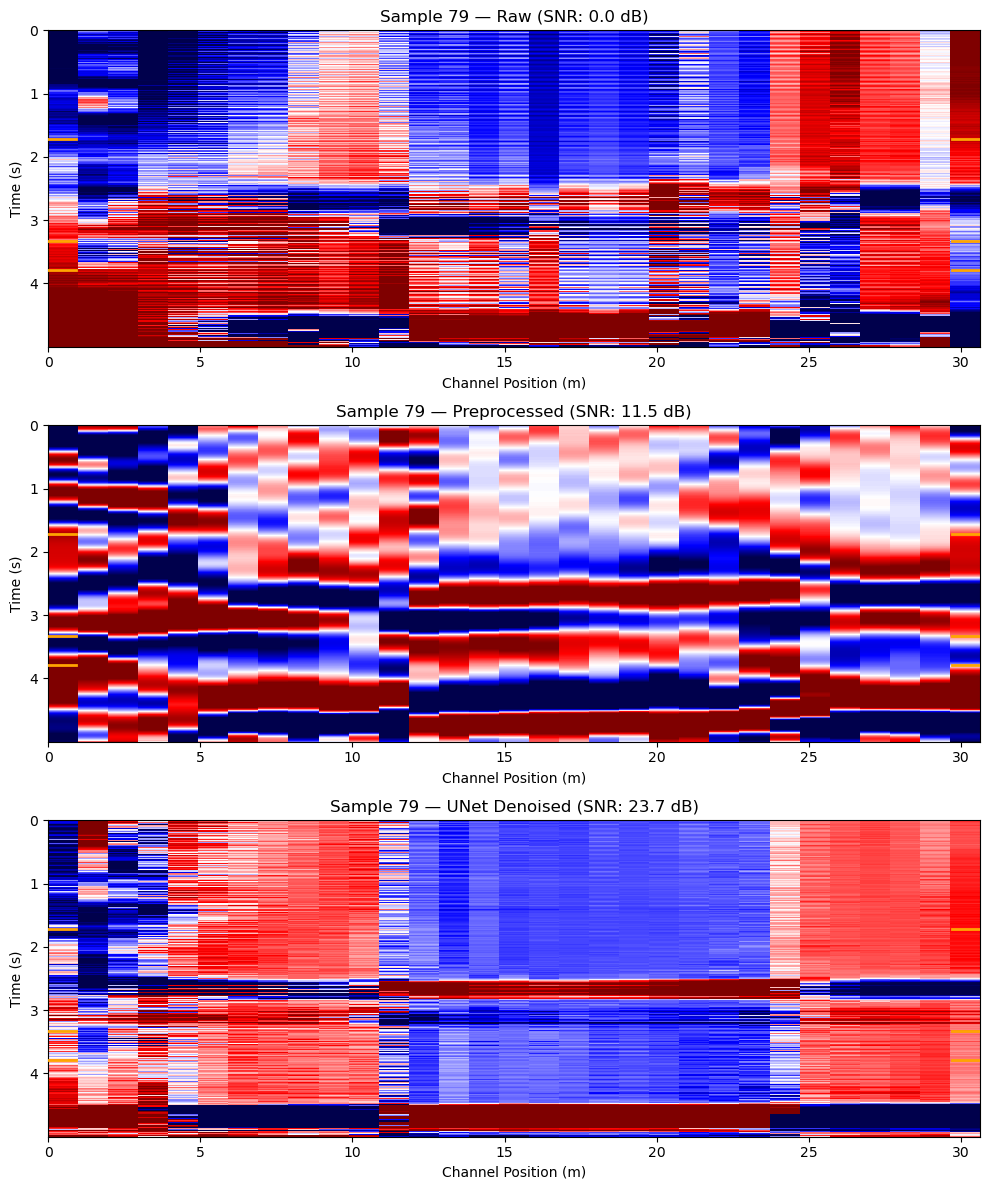

SNR  raw=0.00 dB | pp=11.46 dB | denoised=23.70 dB


In [7]:
from Utilities import plot_das_data, compute_snr
import matplotlib.pyplot as plt

# Requires: python prepare_data.py + python train.py --task denoising + python predict.py --task denoising
SAMPLE_IDX = 8  # change to inspect different test samples

fps_video = ds_cfg["fps_video"]

row = test_df.iloc[SAMPLE_IDX]
sid = row["sample_id"]
raw   = np.load(row["data_path"]).astype(np.float32)
clean = pp(raw, FS_DAS).astype(np.float32)

# Load precomputed denoised output — already in clean signal units (pred_norm * std, no DC)
denoised_path = os.path.join(DATA_DIR, "denoised", f"denoised_sample_{sid:06d}.npy")
pred = np.load(denoised_path).astype(np.float32)

rects = json.loads(row["signal_rects"])
win_start_frame = row["start_frame"]

snr_raw   = compute_snr(raw,   rects, win_start_frame, fps_video, FS_DAS)
snr_clean = compute_snr(clean, rects, win_start_frame, fps_video, FS_DAS)
snr_pred  = compute_snr(pred,  rects, win_start_frame, fps_video, FS_DAS)

channels = np.arange(raw.shape[0])
fig, axes = plt.subplots(3, 1, figsize=(10, 12))
plot_das_data(data=raw,   channels=channels, dx=dx, dt=dt,
              title=f"Sample {sid} — Raw (SNR: {snr_raw:.1f} dB)",
              ax=axes[0], fig=fig, show=False)
plot_das_data(data=clean, channels=channels, dx=dx, dt=dt,
              title=f"Sample {sid} — Preprocessed (SNR: {snr_clean:.1f} dB)",
              ax=axes[1], fig=fig, show=False)
plot_das_data(data=pred,  channels=channels, dx=dx, dt=dt,
              title=f"Sample {sid} — UNet Denoised (SNR: {snr_pred:.1f} dB)",
              ax=axes[2], fig=fig, show=False)

for ax in axes:
    for r_s, r_e in rects:
        t_s = (r_s - win_start_frame) / fps_video
        t_e = (r_e - win_start_frame) / fps_video
        for t in (t_s, t_e):
            ax.axhline(t, xmin=0, xmax=0.03, color="orange", linewidth=2, zorder=3)
            ax.axhline(t, xmin=0.97, xmax=1.0, color="orange", linewidth=2, zorder=3)

plt.tight_layout()
plt.show()
print(f"SNR  raw={snr_raw:.2f} dB | pp={snr_clean:.2f} dB | denoised={snr_pred:.2f} dB")

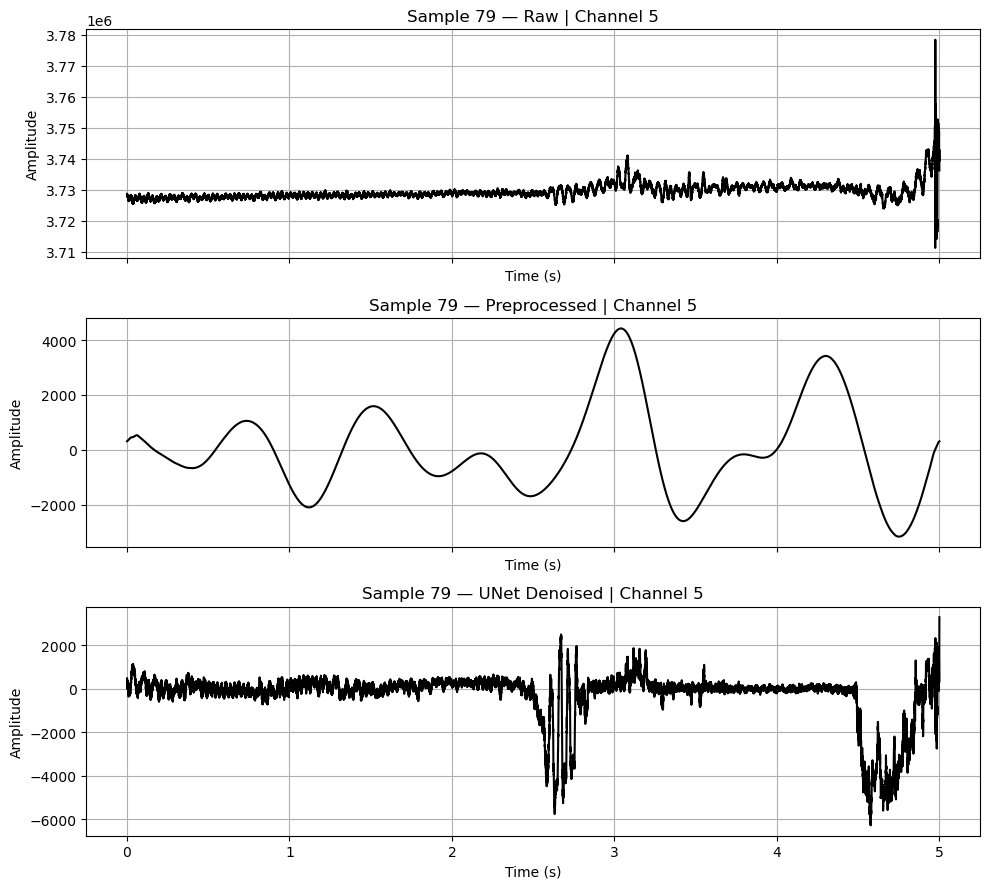

In [8]:
from Utilities import plot_single
import matplotlib.pyplot as plt

CHANNEL = 5  # channel to inspect
T0, T1 = 0, 5

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

plot_single(data=raw,   channel_num=CHANNEL, dx=dx, dt=dt, start_time=T0, end_time=T1, ax=axes[0], show=False)
axes[0].set_title(f"Sample {sid} — Raw | Channel {CHANNEL}")

plot_single(data=clean, channel_num=CHANNEL, dx=dx, dt=dt, start_time=T0, end_time=T1, ax=axes[1], show=False)
axes[1].set_title(f"Sample {sid} — Preprocessed | Channel {CHANNEL}")

plot_single(data=pred,  channel_num=CHANNEL, dx=dx, dt=dt, start_time=T0, end_time=T1, ax=axes[2], show=False)
axes[2].set_title(f"Sample {sid} — UNet Denoised | Channel {CHANNEL}")

plt.tight_layout()
plt.show()

In [9]:
# Run `python predict.py --task denoising` to regenerate denoised samples
denoised_dir = os.path.join(DATA_DIR, "denoised")
print(f"Denoised samples → {denoised_dir}/  |  Run: python predict.py --task denoising")

Denoised samples → data/newville_nov2025/denoised/  |  Run: python predict.py --task denoising
